# 📧 Spam Mail Detection
### Complete ML Pipeline: Data Cleaning → EDA → Model Building → Comparison

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset

In [2]:
# ✅ Update path if needed — place mail_data.csv in the same folder as this notebook
df = pd.read_csv('/content/mail_data.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (5572, 2)
Columns: ['Category', 'Message']


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 🧹 Step 3: Data Cleaning & Preprocessing

### 3.1 — Check & Handle Missing Values

In [3]:
print('=== Missing Values Before Cleaning ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Drop rows with any missing values
df.dropna(inplace=True)

print('\n=== Missing Values After Cleaning ===')
print(df.isnull().sum())
print(f'\nDataset shape after handling missing values: {df.shape}')

=== Missing Values Before Cleaning ===
Category    0
Message     0
dtype: int64

Total missing values: 0

=== Missing Values After Cleaning ===
Category    0
Message     0
dtype: int64

Dataset shape after handling missing values: (5572, 2)


### 3.2 — Remove Duplicates

In [4]:
print(f'Total rows before removing duplicates : {df.shape[0]}')
print(f'Duplicate rows found                  : {df.duplicated().sum()}')

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Total rows after  removing duplicates : {df.shape[0]}')

Total rows before removing duplicates : 5572
Duplicate rows found                  : 415
Total rows after  removing duplicates : 5157


### 3.3 — Encode Labels

In [5]:
# Encode: spam = 0, Not spam = 1
df['Label'] = df['Category'].map({'spam': 0, 'ham': 1})

print('Label encoding:')
print('  spam → 0')
print('  Not spam  → 1')
print()
print(df[['Category', 'Label']].value_counts())
df.head()

Label encoding:
  spam → 0
  Not spam  → 1

Category  Label
ham       1        4516
spam      0         641
Name: count, dtype: int64


,Category,Message,Label
0,ham,"Go until jurong point, crazy.. Available only ...",1
1,ham,Ok lar... Joking wif u oni...,1
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0
3,ham,U dun say so early hor... U c already then say...,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",1


### 3.4 — TF-IDF Vectorization

In [6]:
# Convert text messages to numeric TF-IDF features
X_text = df['Message']
y      = df['Label']

tfidf = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)
X_tfidf = tfidf.fit_transform(X_text)

print(f'TF-IDF feature matrix shape: {X_tfidf.shape}')
print(f'Total vocabulary size       : {len(tfidf.vocabulary_)}')

TF-IDF feature matrix shape: (5157, 8440)
Total vocabulary size       : 8440


### 3.5 — Feature Scaling (StandardScaler & MinMaxScaler)

In [7]:
# Convert sparse TF-IDF to dense for scaling demo
X_dense = X_tfidf.toarray()

# --- StandardScaler ---
std_scaler   = StandardScaler()
X_standard   = std_scaler.fit_transform(X_dense)

# --- MinMaxScaler ---
minmax_scaler = MinMaxScaler()
X_minmax      = minmax_scaler.fit_transform(X_dense)

print('StandardScaler — sample stats (first feature):')
print(f'  Mean  : {X_standard[:, 0].mean():.4f}  (target ≈ 0)')
print(f'  Std   : {X_standard[:, 0].std():.4f}   (target ≈ 1)')

print('\nMinMaxScaler — sample stats (first feature):')
print(f'  Min   : {X_minmax[:, 0].min():.4f}  (target = 0.0)')
print(f'  Max   : {X_minmax[:, 0].max():.4f}  (target = 1.0)')

print('\n✅ Feature scaling applied successfully!')

StandardScaler — sample stats (first feature):
  Mean  : -0.0000  (target ≈ 0)
  Std   : 1.0000   (target ≈ 1)

MinMaxScaler — sample stats (first feature):
  Min   : 0.0000  (target = 0.0)
  Max   : 1.0000  (target = 1.0)

✅ Feature scaling applied successfully!


## 📊 Step 4: Exploratory Data Analysis (EDA)

### 4.1 — Dataset Overview

In [8]:
print('=== Dataset Info ===')
print(df.info())
print()
print('=== Basic Statistics ===')
print(df.describe(include='all'))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5157 entries, 0 to 5156
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5157 non-null   object
 1   Message   5157 non-null   object
 2   Label     5157 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 121.0+ KB
None

=== Basic Statistics ===
       Category                     Message        Label
count      5157                        5157  5157.000000
unique        2                        5157          NaN
top         ham  Rofl. Its true to its name          NaN
freq       4516                           1          NaN
mean        NaN                         NaN     0.875703
std         NaN                         NaN     0.329952
min         NaN                         NaN     0.000000
25%         NaN                         NaN     1.000000
50%         NaN                         NaN     1.000000
75%         NaN               

### 4.2 — Spam vs Not spam Distribution (Count & Pie)

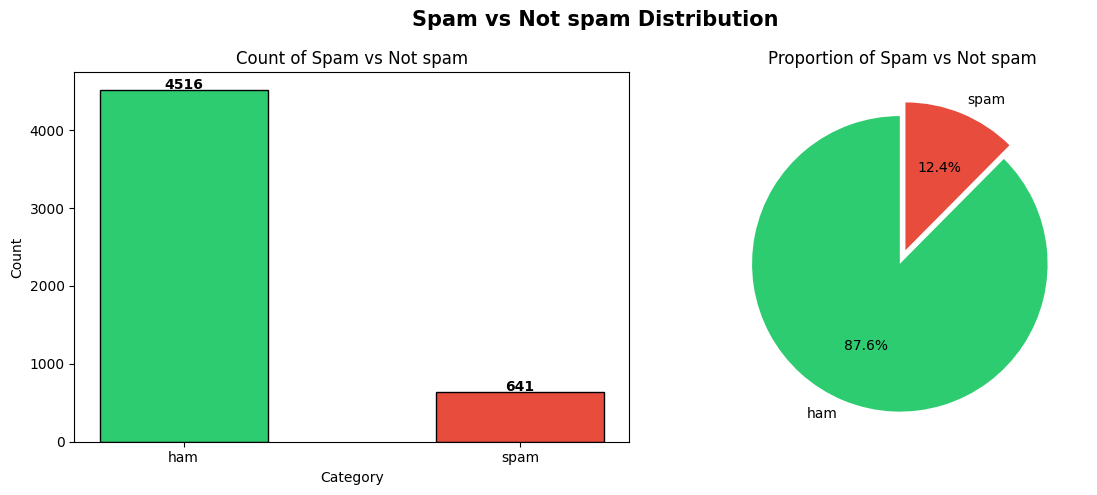

Spam count     : 641
Not spam count : 4516


In [9]:
label_counts = df['Category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Spam vs Not spam Distribution', fontsize=15, fontweight='bold')

# Count plot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Count of Spam vs Not spam')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proportion of Spam vs Not spam')

plt.tight_layout()
plt.savefig('01_spam_ham_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Spam count     :', label_counts.get('spam', 0))
print('Not spam count :', label_counts.get('ham', 0))

### 4.3 — Message Length Analysis

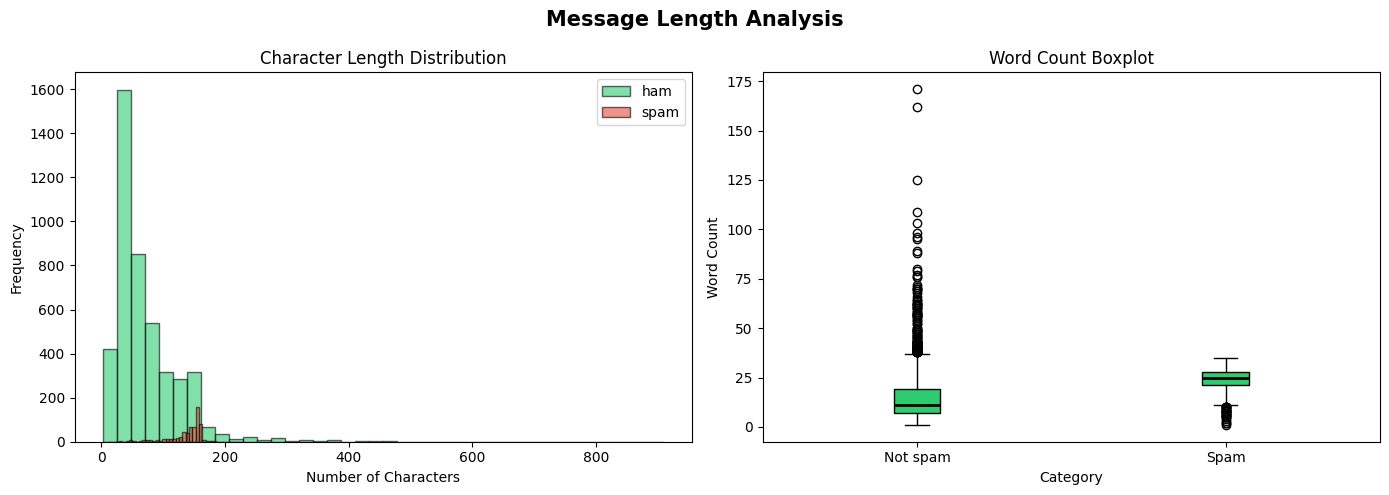

Average character length:
Category
ham      70.87
spam    137.12
Name: msg_length, dtype: float64

Average word count:
Category
ham     14.24
spam    23.66
Name: word_count, dtype: float64


In [10]:
df['msg_length'] = df['Message'].apply(len)
df['word_count'] = df['Message'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Message Length Analysis', fontsize=15, fontweight='bold')

# Character length histogram
for cat, col in zip(['ham', 'spam'], ['#2ecc71', '#e74c3c']):
    axes[0].hist(df[df['Category'] == cat]['msg_length'], bins=40,
                 alpha=0.6, color=col, label=cat, edgecolor='black')
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count boxplot
spam_words = df[df['Category'] == 'spam']['word_count']
ham_words  = df[df['Category'] == 'ham']['word_count']
axes[1].boxplot([ham_words, spam_words], labels=['Not spam', 'Spam'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Word Count Boxplot')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('02_message_length.png', dpi=120, bbox_inches='tight')
plt.show()

print('Average character length:')
print(df.groupby('Category')['msg_length'].mean().round(2))
print('\nAverage word count:')
print(df.groupby('Category')['word_count'].mean().round(2))

### 4.4 — Top 15 Most Frequent Words in Spam vs Not spam

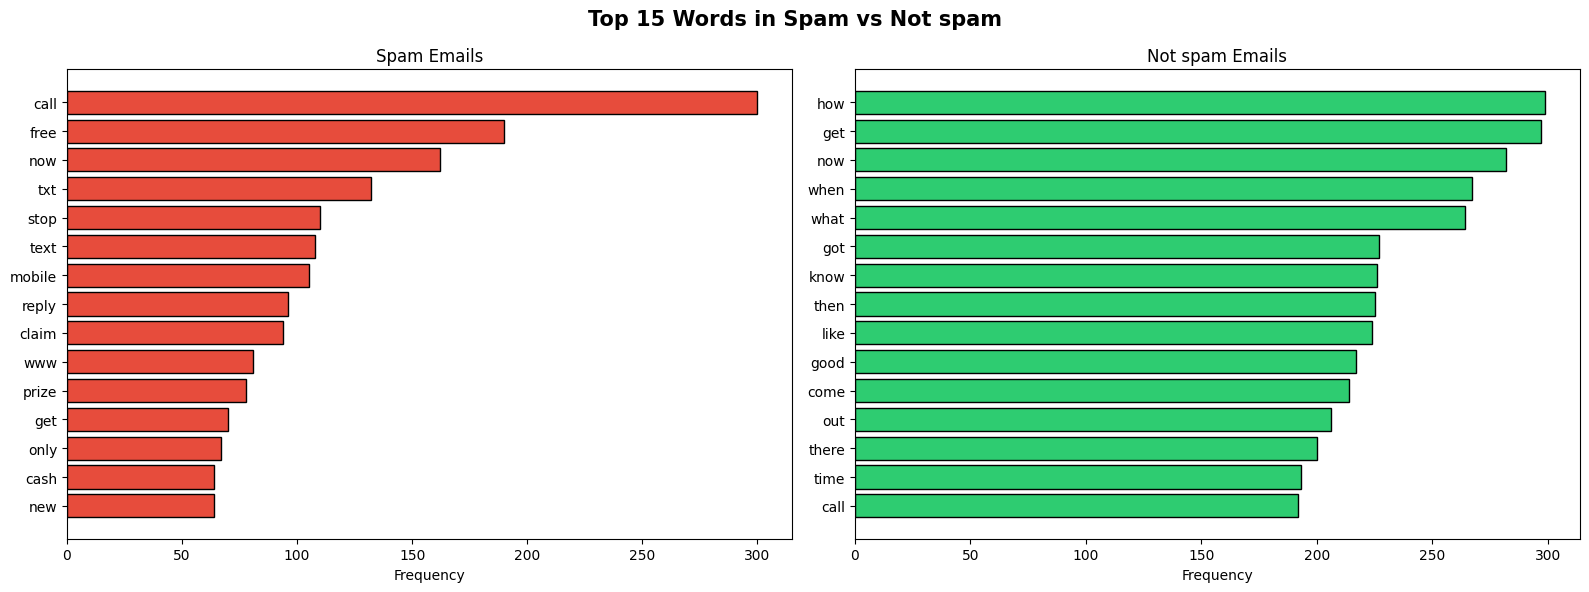

In [11]:
from collections import Counter
import re

def get_top_words(text_series, n=15):
    all_words = ' '.join(text_series).lower()
    words = re.findall(r'\b[a-z]{3,}\b', all_words)
    stopwords = {'the','and','for','you','your','this','that','are','have',
                 'will','with','from','just','not','but','can','our','all',
                 'has','was','its','been','also','more','they','their'}
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

spam_words_top = get_top_words(df[df['Category'] == 'spam']['Message'])
ham_words_top  = get_top_words(df[df['Category'] == 'ham']['Message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 Words in Spam vs Not spam', fontsize=15, fontweight='bold')

for ax, data, title, color in zip(
    axes,
    [spam_words_top, ham_words_top],
    ['Spam Emails', 'Not spam Emails'],
    ['#e74c3c', '#2ecc71']
):
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('03_top_words.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.5 — Correlation Heatmap (Numeric Features)

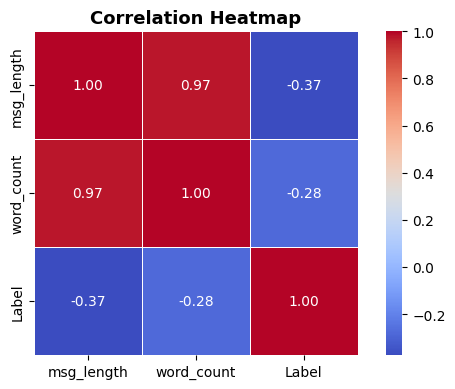

In [12]:
numeric_df = df[['msg_length', 'word_count', 'Label']]
corr = numeric_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 🤖 Step 5: ML Models — Train & Evaluate

### 5.1 — Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Test set size     : {X_test.shape[0]} samples')
print(f'Features          : {X_train.shape[1]}')

Training set size : 4125 samples
Test set size     : 1032 samples
Features          : 8440


### 5.2 — Model 1: Logistic Regression (Binary Classification)

In [14]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_train_pred = lr_model.predict(X_train)
lr_test_pred  = lr_model.predict(X_test)

lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc  = accuracy_score(y_test,  lr_test_pred)

print('=======================================')
print('     Model 1: Logistic Regression')
print('=======================================')
print(f'  Training Accuracy : {lr_train_acc * 100:.2f}%')
print(f'  Test Accuracy     : {lr_test_acc  * 100:.2f}%')
print()
print('Classification Report (Test):')
print(classification_report(y_test, lr_test_pred, target_names=['Spam', 'Not spam']))

     Model 1: Logistic Regression
  Training Accuracy : 96.34%
  Test Accuracy     : 95.35%

Classification Report (Test):
              precision    recall  f1-score   support

        Spam       0.99      0.63      0.77       128
    Not spam       0.95      1.00      0.97       904

    accuracy                           0.95      1032
   macro avg       0.97      0.82      0.87      1032
weighted avg       0.96      0.95      0.95      1032



### 5.3 — Model 2: Linear Regression (used as Classifier via threshold)

In [15]:
# Linear Regression predicts continuous values; threshold at 0.5 for binary class
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_train_pred_raw = lin_model.predict(X_train)
lin_test_pred_raw  = lin_model.predict(X_test)

# Apply threshold
lin_train_pred = (lin_train_pred_raw >= 0.5).astype(int)
lin_test_pred  = (lin_test_pred_raw  >= 0.5).astype(int)

lin_train_acc = accuracy_score(y_train, lin_train_pred)
lin_test_acc  = accuracy_score(y_test,  lin_test_pred)

print('=======================================')
print('     Model 2: Linear Regression')
print(' (threshold=0.5 for binary prediction)')
print('=======================================')
print(f'  Training Accuracy : {lin_train_acc * 100:.2f}%')
print(f'  Test Accuracy     : {lin_test_acc  * 100:.2f}%')
print()
print('Classification Report (Test):')
print(classification_report(y_test, lin_test_pred, target_names=['Spam', 'Not spam']))

     Model 2: Linear Regression
 (threshold=0.5 for binary prediction)
  Training Accuracy : 100.00%
  Test Accuracy     : 96.80%

Classification Report (Test):
              precision    recall  f1-score   support

        Spam       0.99      0.75      0.85       128
    Not spam       0.97      1.00      0.98       904

    accuracy                           0.97      1032
   macro avg       0.98      0.87      0.92      1032
weighted avg       0.97      0.97      0.97      1032



### 5.4 — Model 3: Naive Bayes (MultinomialNB)

In [16]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_train_pred = nb_model.predict(X_train)
nb_test_pred  = nb_model.predict(X_test)

nb_train_acc = accuracy_score(y_train, nb_train_pred)
nb_test_acc  = accuracy_score(y_test,  nb_test_pred)

print('=======================================')
print('     Model 3: Naive Bayes (MultinomialNB)')
print('=======================================')
print(f'  Training Accuracy : {nb_train_acc * 100:.2f}%')
print(f'  Test Accuracy     : {nb_test_acc  * 100:.2f}%')
print()
print('Classification Report (Test):')
print(classification_report(y_test, nb_test_pred, target_names=['Spam', 'Not spam']))

     Model 3: Naive Bayes (MultinomialNB)
  Training Accuracy : 97.58%
  Test Accuracy     : 96.80%

Classification Report (Test):
              precision    recall  f1-score   support

        Spam       1.00      0.74      0.85       128
    Not spam       0.96      1.00      0.98       904

    accuracy                           0.97      1032
   macro avg       0.98      0.87      0.92      1032
weighted avg       0.97      0.97      0.97      1032



## 📈 Step 6: Model Comparison

### 6.1 — Accuracy Comparison Table

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear Regression', 'Naive Bayes'],
    'Train Accuracy (%)': [
        round(lr_train_acc * 100, 2),
        round(lin_train_acc * 100, 2),
        round(nb_train_acc * 100, 2)
    ],
    'Test Accuracy (%)': [
        round(lr_test_acc * 100, 2),
        round(lin_test_acc * 100, 2),
        round(nb_test_acc * 100, 2)
    ]
})

results = results.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
print('=== Model Accuracy Comparison ===')
print(results.to_string(index=False))
print(f'\n🏆 Best Model: {results.iloc[0]["Model"]} ({results.iloc[0]["Test Accuracy (%)"]:.2f}% test accuracy)')

=== Model Accuracy Comparison ===
              Model  Train Accuracy (%)  Test Accuracy (%)
  Linear Regression              100.00              96.80
        Naive Bayes               97.58              96.80
Logistic Regression               96.34              95.35

🏆 Best Model: Linear Regression (96.80% test accuracy)


### 6.2 — Accuracy Bar Chart Comparison

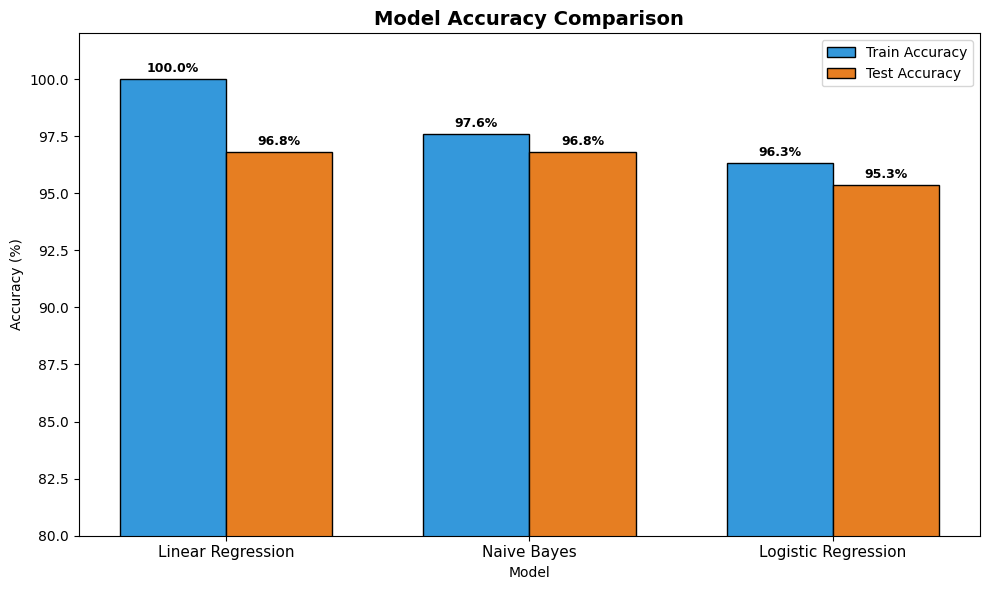

In [18]:
models      = results['Model']
train_accs  = results['Train Accuracy (%)']
test_accs   = results['Test Accuracy (%)']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='#e67e22', edgecolor='black')

ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(80, 102)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 — Confusion Matrices (All Models)

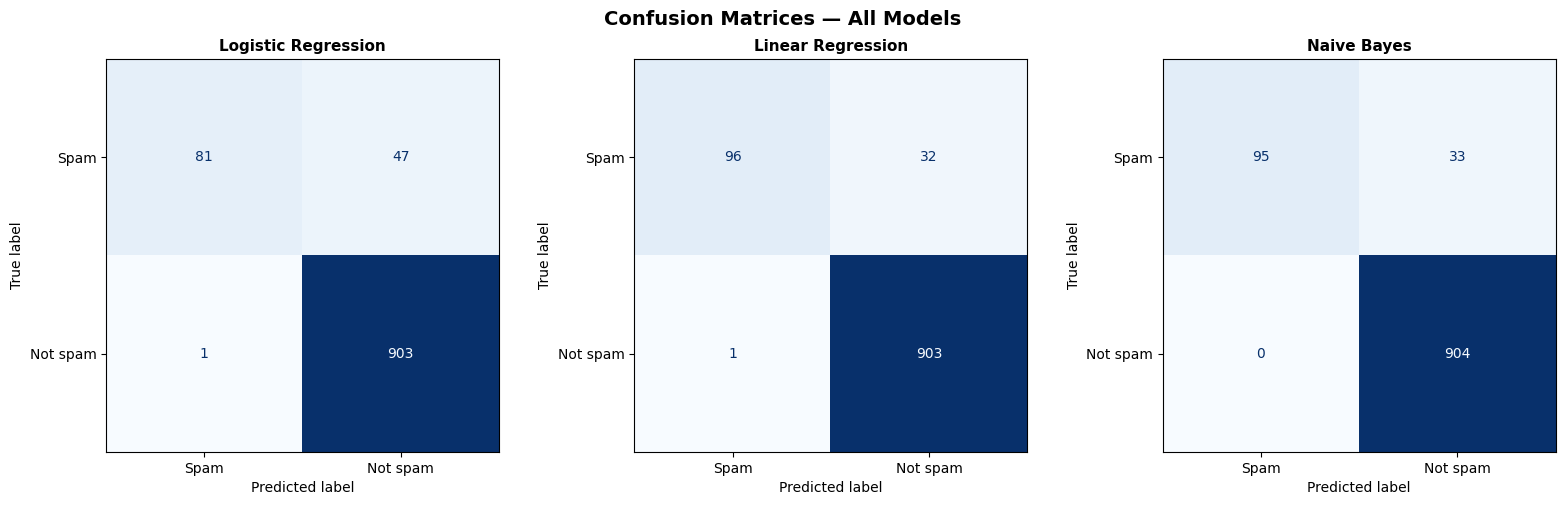

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

model_data = [
    ('Logistic Regression', lr_test_pred),
    ('Linear Regression',   lin_test_pred),
    ('Naive Bayes',         nb_test_pred)
]

for ax, (name, preds) in zip(axes, model_data):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spam', 'Not spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('06_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔍 Step 7: Predict on New Email

In [20]:
def predict_email(email_text, model=lr_model, vectorizer=tfidf):
    """Predict whether an email is spam or Not spam."""
    features   = vectorizer.transform([email_text])
    prediction = model.predict(features)[0]
    label      = 'NOT SPAM ✅' if prediction == 1 else 'SPAM 🚨'
    print(f'Email   : "{email_text[:80]}..."' if len(email_text) > 80 else f'Email   : "{email_text}"')
    print(f'Result  : {label}')
    print()

# --- Test Samples ---
print('=== Email Prediction Results ===')
print()

predict_email("Congratulations! You've won a FREE iPhone. Click here to claim now!!!")
predict_email("Hi, can we reschedule our meeting to 3pm tomorrow? Let me know.")
predict_email("URGENT: Your account has been suspended. Verify now to avoid permanent ban!")
predict_email("Hey, I attached the report you asked for. Let me know if you need any changes.")

=== Email Prediction Results ===

Email   : "Congratulations! You've won a FREE iPhone. Click here to claim now!!!"
Result  : SPAM 🚨

Email   : "Hi, can we reschedule our meeting to 3pm tomorrow? Let me know."
Result  : NOT SPAM ✅

Email   : "URGENT: Your account has been suspended. Verify now to avoid permanent ban!"
Result  : NOT SPAM ✅

Email   : "Hey, I attached the report you asked for. Let me know if you need any changes."
Result  : NOT SPAM ✅



## ✅ Step 8: Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Import Libraries | ✅ Done |
| 2 | Load Dataset | ✅ Done |
| 3 | Handle Missing Values | ✅ Done |
| 4 | Remove Duplicates | ✅ Done |
| 5 | Feature Scaling (StandardScaler + MinMaxScaler) | ✅ Done |
| 6 | EDA — Distribution, Length, Word Freq, Heatmap | ✅ Done |
| 7 | Linear Regression Model | ✅ Done |
| 8 | Logistic Regression Model | ✅ Done |
| 9 | Naive Bayes Model | ✅ Done |
| 10 | Model Accuracy Comparison | ✅ Done |
| 11 | Confusion Matrices | ✅ Done |
| 12 | Predict on New Emails | ✅ Done |